<a href="https://colab.research.google.com/github/ihinck413/Econ-5120/blob/main/Econ_5200_Homework_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install yfinance pandas

Part A

In [3]:
import yfinance as yf
import pandas as pd

# Define the tickers for S&P 500 and S&P 500 Total Return Index
tickers = {
    'SP500': '^GSPC',
    'SP500_TR': '^SP500TR'
}

# Fetch historical data up to August 31, 2025
# We fetch until 2025-09-01 to ensure the last day of August is included
start_date = '1900-01-01'
end_date = '2025-09-01'

data_list = []
for name, ticker in tickers.items():
    # By default, yfinance auto_adjusts historical prices, so 'Close' contains the adjusted close.
    ticker_data = yf.download(ticker, start=start_date, end=end_date)['Close']
    ticker_data.name = name
    data_list.append(ticker_data)

# Combine the data into a single DataFrame
df = pd.concat(data_list, axis=1)

# Drop any rows where both are NaN
df = df.dropna(how='all')

# Resample to get the last business day of each month
# 'ME' represents Month End frequency
monthly_df = df.resample('ME').last()

# Display the final monthly dataset
display(monthly_df)

/tmp/ipykernel_2163/124670904.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ticker_data = yf.download(ticker, start=start_date, end=end_date)['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2163/124670904.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ticker_data = yf.download(ticker, start=start_date, end=end_date)['Close']
[*********************100%***********************]  1 of 1 completed


Ticker,^GSPC,^SP500TR
Date,,
1927-12-31,17.660000,NaN
1928-01-31,17.570000,NaN
1928-02-29,17.260000,NaN
1928-03-31,19.280001,NaN
1928-04-30,19.750000,NaN
...,...,...
2025-04-30,5569.060059,12276.389648
2025-05-31,5911.689941,13049.129883
2025-06-30,6204.950195,13712.709961


In [4]:
import pandas as pd
import numpy as np

file_path = '/content/ie_data_fixed_dates_2.xlsx'

# Read the spreadsheet
try:
    df_raw = pd.read_excel(file_path, sheet_name='Data', skiprows=7)
except Exception:
    df_raw = pd.read_excel(file_path, skiprows=7)

# Standardize column headers
df_raw.columns = [str(col).strip() for col in df_raw.columns]

# Map columns: first column is Date, second is Price (P), third is Dividend (D)
rename_mapping = {
    df_raw.columns[0]: 'Date',
    df_raw.columns[1]: 'P',
    df_raw.columns[2]: 'D'
}

shiller_df = df_raw.rename(columns=rename_mapping)[['Date', 'P', 'D']]

# Drop rows where Date is missing
shiller_df = shiller_df.dropna(subset=['Date'])

# Ensure Date column is treated as string to parse the MM/YYYY or YYYY.MM format robustly
shiller_df['Date'] = shiller_df['Date'].astype(str).str.strip()

# Parse the dates (handles '01/1871', '1/1871', '1871.01', etc.)
def robust_parse_date(x):
    try:
        if '/' in x:
            parts = x.split('/')
            month = int(parts[0])
            year = int(parts[1])
            return pd.Timestamp(year=year, month=month, day=1)
        else:
            # Fallback for Year.Month numeric style
            val = float(x)
            year = int(val)
            month = int(round((val - year) * 100))
            if month < 1 or month > 12:
                month = 1
            return pd.Timestamp(year=year, month=month, day=1)
    except:
        return pd.NaT

shiller_df['Date'] = shiller_df['Date'].apply(robust_parse_date)
shiller_df = shiller_df.dropna(subset=['Date'])

# Convert Date column to DatetimeIndex
shiller_df = shiller_df.set_index(pd.DatetimeIndex(shiller_df['Date'])).drop(columns=['Date'])

# Convert price and dividends to numeric
shiller_df['P'] = pd.to_numeric(shiller_df['P'], errors='coerce')
shiller_df['D'] = pd.to_numeric(shiller_df['D'], errors='coerce')
shiller_df = shiller_df.dropna(subset=['P'])

# Filter to start from 1871
shiller_df = shiller_df[shiller_df.index >= '1871-01-01']

# Shift to end of month to align indexes
shiller_df.index = shiller_df.index + pd.offsets.MonthEnd(0)

# Display the resulting DataFrame
display(shiller_df.head())
display(shiller_df.tail())

,P,D
Date,,
1871-01-31,4.44,0.26
1871-02-28,4.50,0.26
1871-03-31,4.61,0.26
1871-04-30,4.74,0.26
1871-05-31,4.86,0.26


,P,D
Date,,
2023-05-31,4146.173182,68.543333
2023-06-30,4345.372857,68.710000
2023-07-31,4508.075500,NaN
2023-08-31,4457.358696,NaN
2023-09-30,4515.770000,NaN


Graph each index

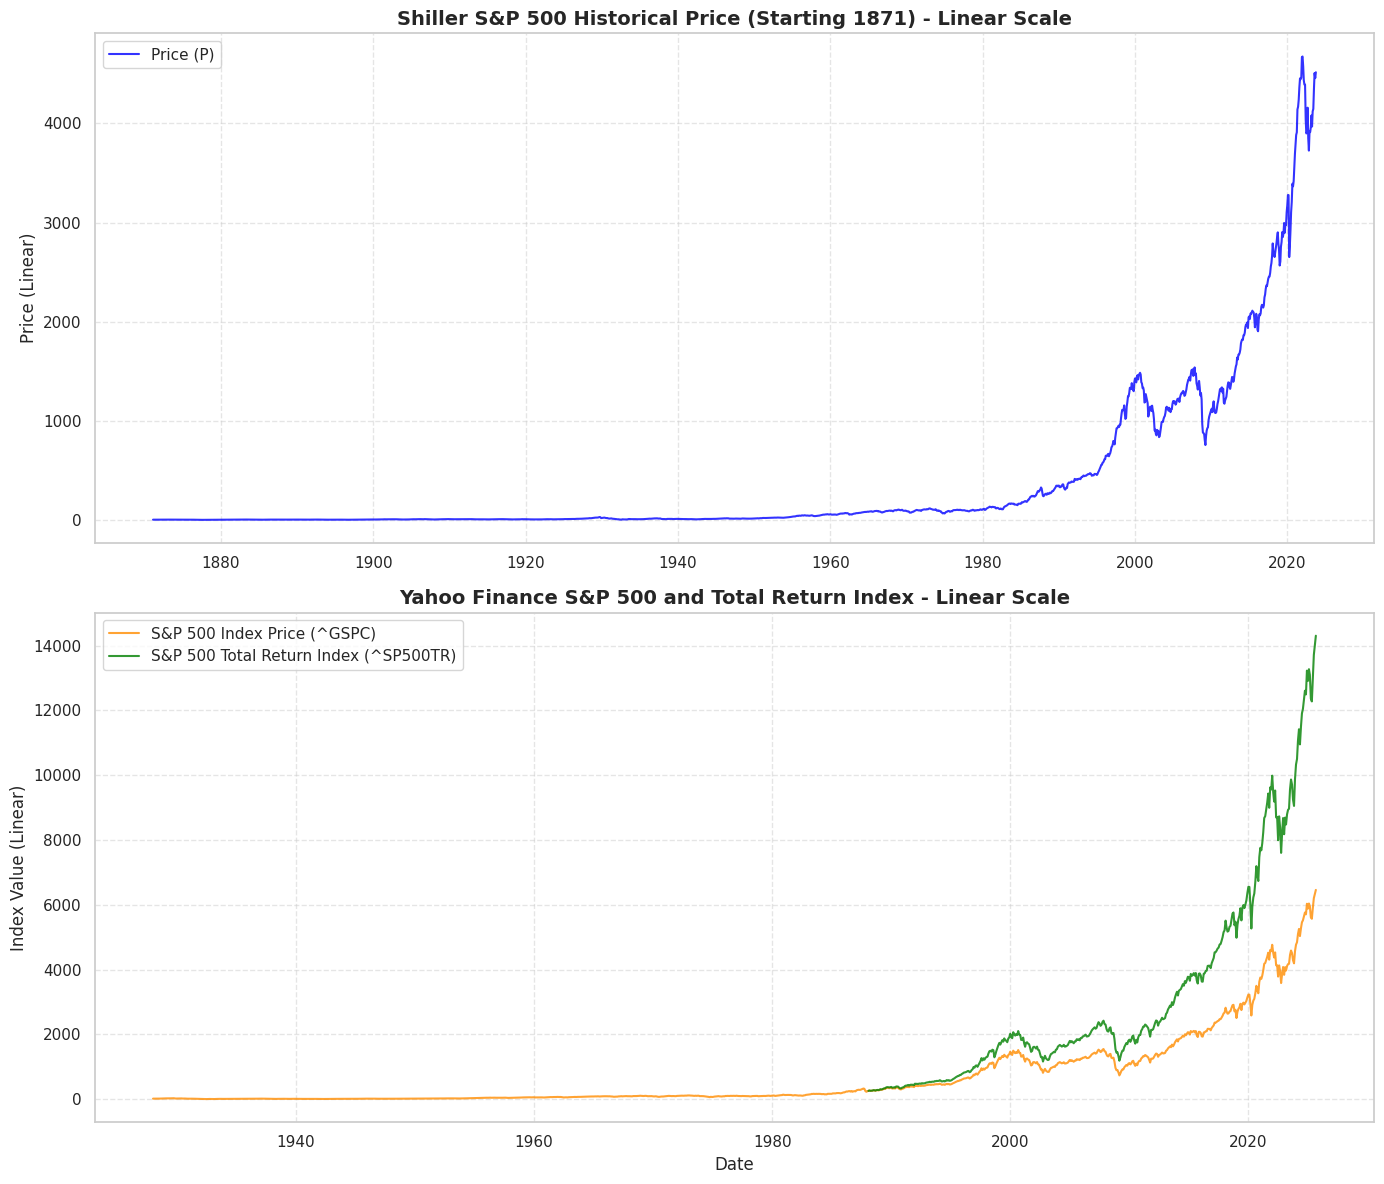

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Create a figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=False)

# Plot 1: Shiller S&P 500 Historical Dataset (Starts in 1871)
axes[0].plot(shiller_df.index, shiller_df['P'], label='Price (P)', color='blue', alpha=0.8)
axes[0].set_title('Shiller S&P 500 Historical Price (Starting 1871) - Linear Scale', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (Linear)', fontsize=12)
axes[0].set_yscale('linear') # Changed from log to linear
axes[0].legend(loc='upper left')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Modern Yahoo Finance S&P 500 & Total Return Index
axes[1].plot(monthly_df.index, monthly_df['^GSPC'], label='S&P 500 Index Price (^GSPC)', color='darkorange', alpha=0.8)
if '^SP500TR' in monthly_df.columns:
    axes[1].plot(monthly_df.index, monthly_df['^SP500TR'], label='S&P 500 Total Return Index (^SP500TR)', color='green', alpha=0.8)

axes[1].set_title('Yahoo Finance S&P 500 and Total Return Index - Linear Scale', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Index Value (Linear)', fontsize=12)
axes[1].set_yscale('linear') # Changed from log to linear
axes[1].legend(loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Combine indices

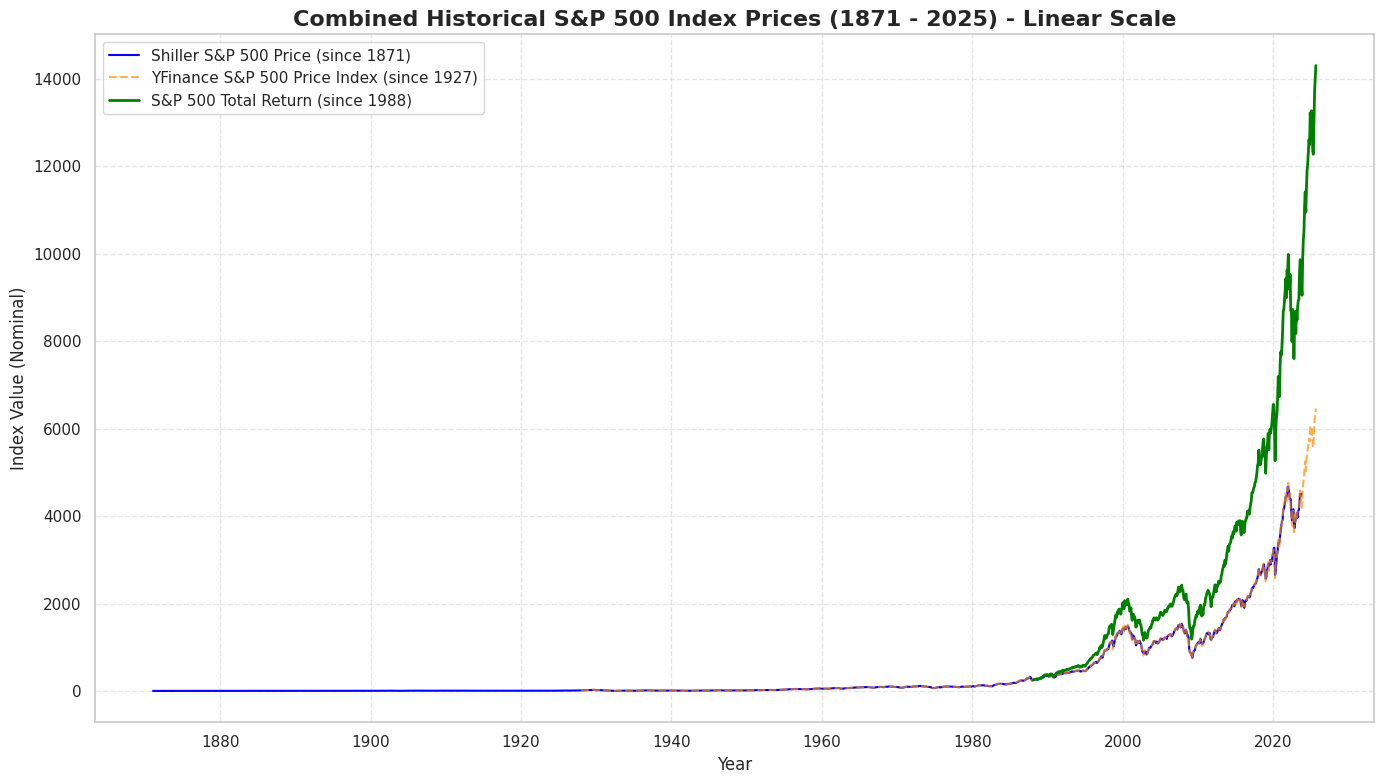

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# Combine the datasets into a single DataFrame for easier plotting
shiller_price = shiller_df[['P']].rename(columns={'P': 'Shiller_Price'})
combined_df = pd.merge(shiller_price, monthly_df, left_index=True, right_index=True, how='outer')

plt.figure(figsize=(14, 8))

# Plot Shiller data (Longest history)
plt.plot(combined_df.index, combined_df['Shiller_Price'], label='Shiller S&P 500 Price (since 1871)', color='blue', linewidth=1.5)

# Plot Yahoo Finance Price Index
plt.plot(combined_df.index, combined_df['^GSPC'], label='YFinance S&P 500 Price Index (since 1927)', color='darkorange', linestyle='--', alpha=0.7)

# Plot Total Return Index if available
if '^SP500TR' in combined_df.columns:
    plt.plot(combined_df.index, combined_df['^SP500TR'], label='S&P 500 Total Return (since 1988)', color='green', linewidth=2)

# Changed scale from log to linear to show real price levels
plt.yscale('linear')
plt.title('Combined Historical S&P 500 Index Prices (1871 - 2025) - Linear Scale', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Index Value (Nominal)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Merge SP500 annd Shiller

In [7]:
import pandas as pd

# Prepare Shiller data
shiller_final = shiller_df[['P', 'D']].rename(columns={'P': 'Price_Shiller', 'D': 'Dividend_Shiller'})

# Prepare Yahoo Finance data
yf_final = monthly_df.rename(columns={'^GSPC': 'Price_YF', '^SP500TR': 'Total_Return_YF'})

# Merge dataframes
merged_df = pd.merge(shiller_final, yf_final, left_index=True, right_index=True, how='outer')

# Create a unified Price column:
# We use Shiller data for the early years, but prioritize Yahoo Finance data once it becomes available (1927 onwards)
merged_df['Unified_Price'] = merged_df['Price_YF'].fillna(merged_df['Price_Shiller'])

# Display the combined dataframe
print("Combined DataFrame Summary:")
display(merged_df.describe())
display(merged_df.head())
display(merged_df.tail())


Combined DataFrame Summary:


,Price_Shiller,Dividend_Shiller,Price_YF,Total_Return_YF,Unified_Price
count,1833.000000,1830.000000,1173.000000,452.000000,1856.000000
mean,376.970841,7.481787,694.662923,3124.680082,441.537408
std,808.285426,13.646061,1171.064105,3144.511249,988.207543
min,2.730000,0.180000,4.430000,257.470001,2.730000
25%,7.930000,0.423300,24.760000,1153.335022,8.025000
50%,18.070000,0.928350,102.910004,1895.244995,19.355000
75%,186.200000,7.706665,1059.780029,3892.334961,249.625000
max,4674.772727,68.710000,6460.259766,14304.679688,6460.259766


,Price_Shiller,Dividend_Shiller,Price_YF,Total_Return_YF,Unified_Price
Date,,,,,
1871-01-31,4.44,0.26,NaN,NaN,4.44
1871-02-28,4.50,0.26,NaN,NaN,4.50
1871-03-31,4.61,0.26,NaN,NaN,4.61
1871-04-30,4.74,0.26,NaN,NaN,4.74
1871-05-31,4.86,0.26,NaN,NaN,4.86


,Price_Shiller,Dividend_Shiller,Price_YF,Total_Return_YF,Unified_Price
Date,,,,,
2025-04-30,NaN,NaN,5569.060059,12276.389648,5569.060059
2025-05-31,NaN,NaN,5911.689941,13049.129883,5911.689941
2025-06-30,NaN,NaN,6204.950195,13712.709961,6204.950195
2025-07-31,NaN,NaN,6339.390137,14020.459961,6339.390137
2025-08-31,NaN,NaN,6460.259766,14304.679688,6460.259766


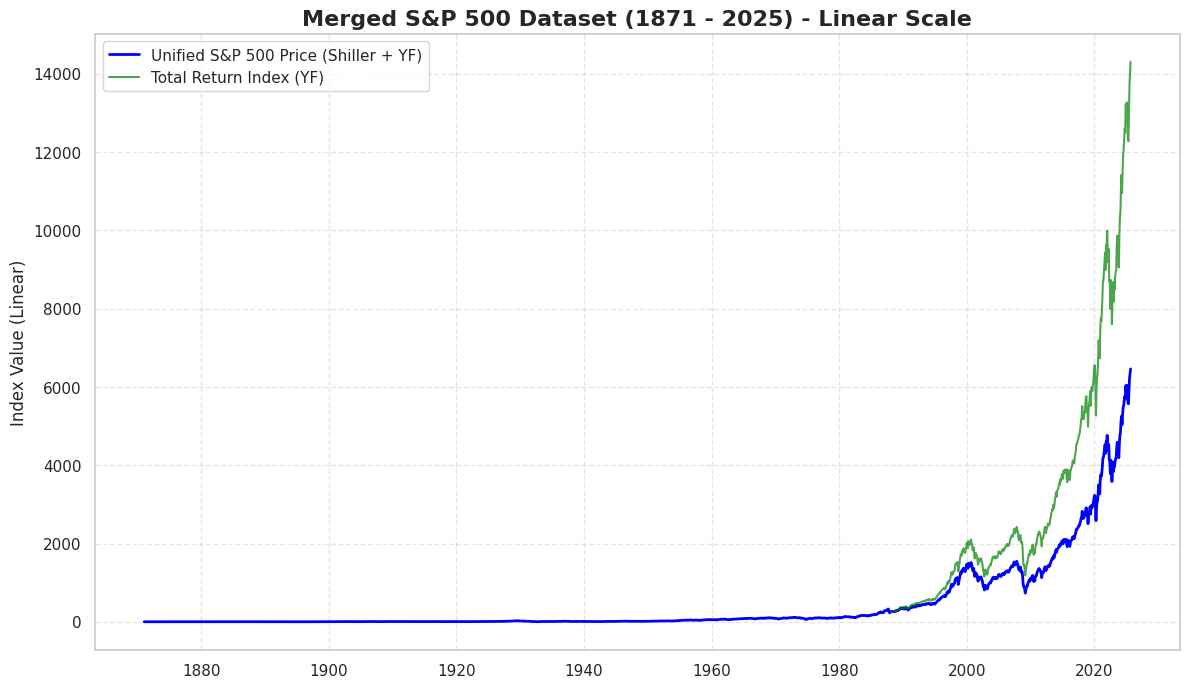

The Shiller data does not match Yahoo Finance as Shiller uses the monthly average close as its index value while Yahoo finance takes the month end close


In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

# Plot the unified Price column
plt.plot(merged_df.index, merged_df['Unified_Price'], label='Unified S&P 500 Price (Shiller + YF)', color='blue', linewidth=2)

# Plot Total Return for comparison
if 'Total_Return_YF' in merged_df.columns:
    plt.plot(merged_df.index, merged_df['Total_Return_YF'], label='Total Return Index (YF)', color='green', alpha=0.7)

plt.yscale('linear') # Changed from log to linear
plt.title('Merged S&P 500 Dataset (1871 - 2025) - Linear Scale', fontsize=16, fontweight='bold')
plt.ylabel('Index Value (Linear)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("The Shiller data does not match Yahoo Finance as Shiller uses the monthly average close as its index value while Yahoo finance takes the month end close")

Part B

--- Validation Results (Since 1988) ---
R-squared of Shiller-based returns vs. Actual TR returns: 0.9998

--- Full Sample Statistics (1871 - 2025) ---
Mean Monthly Return: 0.8454%
Standard Deviation of Monthly Returns: 4.6978%


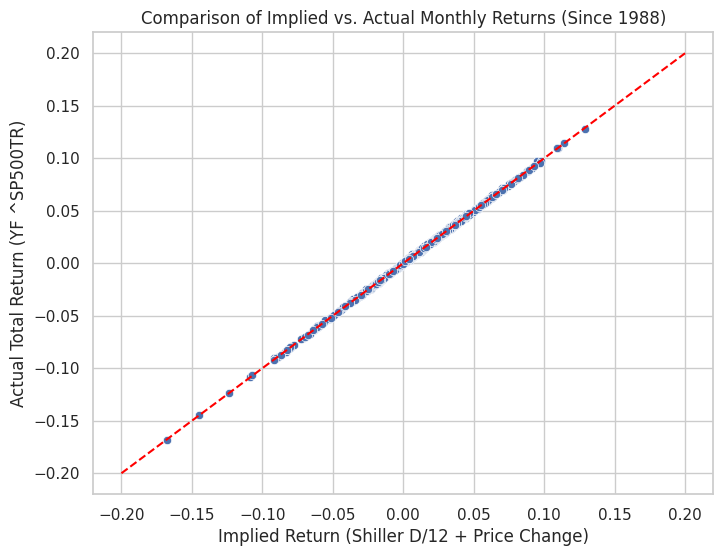

In [9]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. Calculate returns based on Shiller data using the formula: ret = (P + D/12) / lag(P) - 1
# Note: Unified_Price uses YF data where available, but Shiller's D/12 provides the dividend component
merged_df['Shiller_Monthly_Return'] = (merged_df['Unified_Price'] + merged_df['Dividend_Shiller'] / 12) / merged_df['Unified_Price'].shift(1) - 1

# 2. Calculate actual returns from the S&P 500 Total Return Index (YF)
merged_df['Actual_TR_Return'] = merged_df['Total_Return_YF'].pct_change()

# 3. Validation: Compare returns since 1988
validation_df = merged_df.dropna(subset=['Shiller_Monthly_Return', 'Actual_TR_Return'])

X = validation_df[['Shiller_Monthly_Return']].values
y = validation_df['Actual_TR_Return'].values

reg = LinearRegression().fit(X, y)
r2 = r2_score(y, reg.predict(X))

# 4. Full Sample Statistics
full_sample_returns = merged_df['Shiller_Monthly_Return'].dropna()
mean_ret = full_sample_returns.mean()
std_ret = full_sample_returns.std()

print(f"--- Validation Results (Since 1988) ---")
print(f"R-squared of Shiller-based returns vs. Actual TR returns: {r2:.4f}")

print(f"\n--- Full Sample Statistics (1871 - 2025) ---")
print(f"Mean Monthly Return: {mean_ret:.4%}")
print(f"Standard Deviation of Monthly Returns: {std_ret:.4%}")

# Optional: Visualization of the correlation
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.scatterplot(x=validation_df['Shiller_Monthly_Return'], y=validation_df['Actual_TR_Return'])
plt.plot([-0.2, 0.2], [-0.2, 0.2], color='red', linestyle='--') # Identity line
plt.title('Comparison of Implied vs. Actual Monthly Returns (Since 1988)')
plt.xlabel('Implied Return (Shiller D/12 + Price Change)')
plt.ylabel('Actual Total Return (YF ^SP500TR)')
plt.show()

Part C

/tmp/ipykernel_2163/138992560.py:25: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  merged_df['Inflation'] = merged_df['CPI'].pct_change()


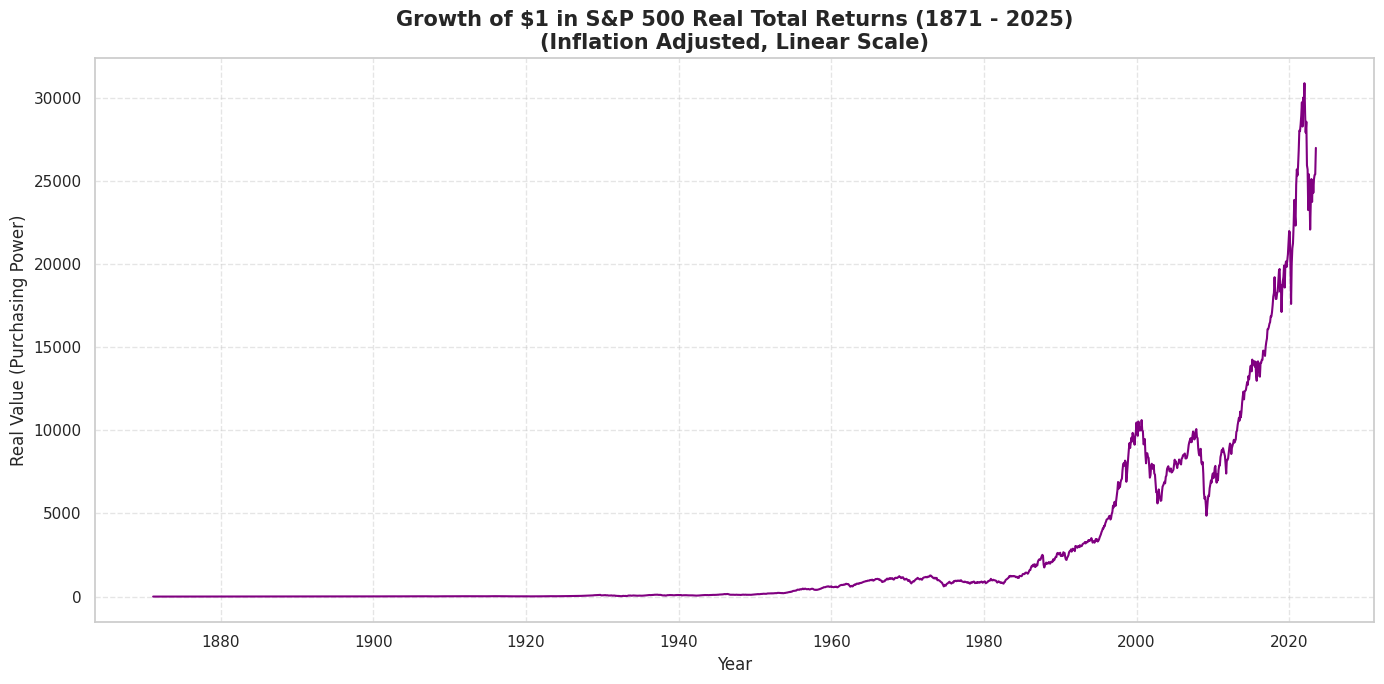

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Extract CPI from df_raw
cpi_col = [col for col in df_raw.columns if 'CPI' in str(col).upper()]
cpi_col_name = cpi_col[0] if cpi_col else df_raw.columns[4]

cpi_df = df_raw[['Date', cpi_col_name]].copy()
cpi_df = cpi_df.rename(columns={cpi_col_name: 'CPI'})
cpi_df['Date'] = cpi_df['Date'].astype(str).str.strip().apply(robust_parse_date)
cpi_df = cpi_df.dropna(subset=['Date', 'CPI'])
cpi_df = cpi_df.set_index(pd.DatetimeIndex(cpi_df['Date'])).drop(columns=['Date'])
cpi_df['CPI'] = pd.to_numeric(cpi_df['CPI'], errors='coerce')
cpi_df = cpi_df[cpi_df.index >= '1871-01-01']
cpi_df.index = cpi_df.index + pd.offsets.MonthEnd(0)

# 2. Merge CPI and calculate Inflation & Real Returns
# Clean up merged_df to prevent suffix collisions if this cell is re-run
for col in ['CPI', 'Inflation', 'Real_Return']:
    if col in merged_df.columns:
        merged_df = merged_df.drop(columns=[col])

merged_df = pd.merge(merged_df, cpi_df, left_index=True, right_index=True, how='left')
merged_df['Inflation'] = merged_df['CPI'].pct_change()

# Real Return Formula: (1 + Nominal_Return) / (1 + Inflation) - 1
merged_df['Real_Return'] = (1 + merged_df['Shiller_Monthly_Return']) / (1 + merged_df['Inflation']) - 1

# 3. Calculate Cumulative Real Returns
real_df = merged_df.dropna(subset=['Real_Return']).copy()
real_df['Cum_Real_Return'] = (1 + real_df['Real_Return']).cumprod()

# 4. Plot Cumulative Real Returns (Linear Scale for Real Return values)
plt.figure(figsize=(14, 7))
plt.plot(real_df.index, real_df['Cum_Real_Return'], color='purple', linewidth=1.5)
plt.yscale('linear')
plt.title('Growth of $1 in S&P 500 Real Total Returns (1871 - 2025)\n(Inflation Adjusted, Linear Scale)', fontsize=15, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Real Value (Purchasing Power)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [11]:
# 5. Calculate Top 5 Drawdowns in Real Returns
real_df['Watermark'] = real_df['Cum_Real_Return'].cummax()
drawdowns = []

# Grouping by Watermark gives us each distinct drawdown period
for peak_val, group in real_df.groupby('Watermark'):
    if len(group) == 1:
        continue # No drawdown occurred here

    peak_date = group.index[0]
    trough_date = group['Cum_Real_Return'].idxmin()
    trough_val = group.loc[trough_date, 'Cum_Real_Return']
    max_dd = (trough_val - peak_val) / peak_val

    # Recovery logic: First time Cum_Real_Return meets or exceeds the peak_val after the trough
    future_dates = real_df.index[real_df.index > trough_date]
    recovery_dates = future_dates[real_df.loc[future_dates, 'Cum_Real_Return'] >= peak_val]

    if len(recovery_dates) > 0:
        recovery_date = recovery_dates[0]
        duration = (recovery_date.year - peak_date.year) * 12 + (recovery_date.month - peak_date.month)
        rec_str = recovery_date.strftime('%Y-%m')
    else:
        # Has not yet recovered by the end of the dataset
        recovery_date = pd.NaT
        duration = (real_df.index[-1].year - peak_date.year) * 12 + (real_df.index[-1].month - peak_date.month)
        rec_str = 'Not Recovered'

    if max_dd < -0.10: # Only consider major drawdowns (worse than -10%)
        drawdowns.append({
            'Peak Date': peak_date.strftime('%Y-%m'),
            'Trough Date': trough_date.strftime('%Y-%m'),
            'Recovery Date': rec_str,
            'Drawdown (%)': max_dd * 100,
            'Duration (Months)': duration
        })

# Sort by worst drawdowns
top_5_drawdowns = pd.DataFrame(drawdowns).sort_values('Drawdown (%)').head(5).reset_index(drop=True)

print("--- Top 5 Historical Drawdowns in S&P 500 Real Total Returns ---")
display(top_5_drawdowns)

--- Top 5 Historical Drawdowns in S&P 500 Real Total Returns ---


,Peak Date,Trough Date,Recovery Date,Drawdown (%),Duration (Months)
0,1929-08,1932-05,1936-10,-78.709288,86
1,2000-08,2009-02,2013-05,-54.163060,153
2,1972-12,1974-09,1985-01,-51.908334,145
3,1937-02,1938-03,1945-02,-49.727181,96
4,1916-11,1920-12,1924-08,-47.127229,93


#1: Great Depression
#2: Tech bubble and GFC
#3: Oil Crisis and Nixon Shock
#4: Roosevelt Recession
#5: War Economy Collapse

Part D

--- Historical Risk and Premium Statistics (1871 - 2025) ---
Average Annual Real Risk-Free Rate (GS10 adjusted for CPI): 2.36%
Average Annual Equity Premium: 5.87%


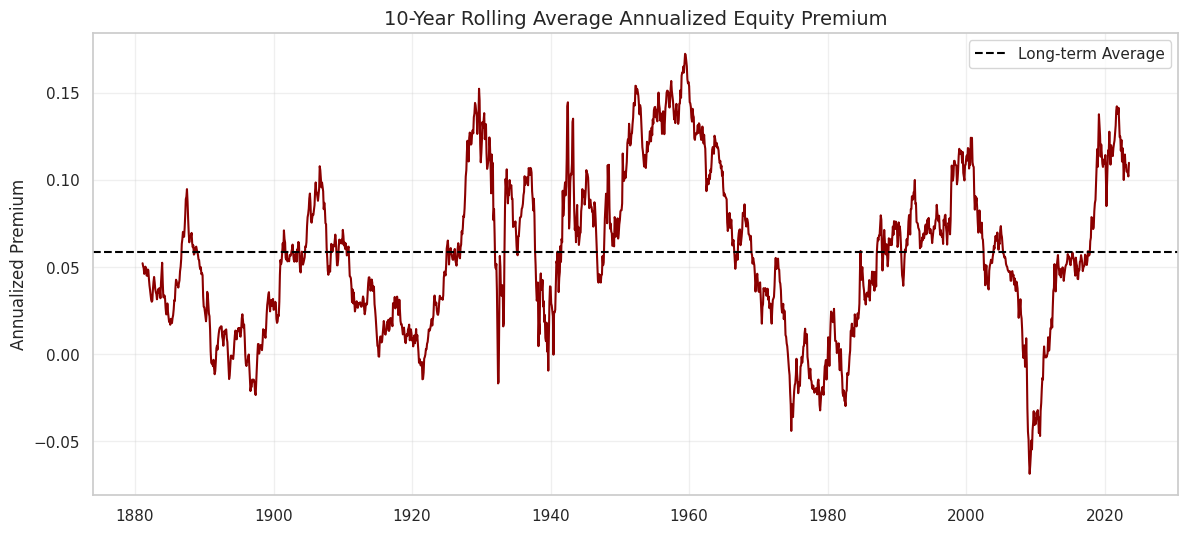

In [12]:
import pandas as pd

# 1. Extract GS10 from df_raw (Typically the column after CPI or labeled GS10/Rate)
gs10_col = [col for col in df_raw.columns if 'GS10' in str(col).upper() or 'RATE' in str(col).upper()]
gs10_col_name = gs10_col[0] if gs10_col else df_raw.columns[6]

rf_df = df_raw[['Date', gs10_col_name]].copy()
rf_df = rf_df.rename(columns={gs10_col_name: 'GS10'})
rf_df['Date'] = rf_df['Date'].astype(str).str.strip().apply(robust_parse_date)
rf_df = rf_df.dropna(subset=['Date', 'GS10'])
rf_df = rf_df.set_index(pd.DatetimeIndex(rf_df['Date'])).drop(columns=['Date'])
rf_df['GS10'] = pd.to_numeric(rf_df['GS10'], errors='coerce')
rf_df.index = rf_df.index + pd.offsets.MonthEnd(0)

# 2. Merge with existing merged_df
merged_df = pd.merge(merged_df, rf_df[['GS10']], left_index=True, right_index=True, how='left')

# 3. Calculate Real Risk-Free Rate
# The GS10 is provided as an annual percentage. We convert to monthly: (1 + r)^(1/12) - 1
merged_df['Nominal_Rf_Monthly'] = (1 + merged_df['GS10']/100)**(1/12) - 1
merged_df['Real_Rf_Monthly'] = (1 + merged_df['Nominal_Rf_Monthly']) / (1 + merged_df['Inflation']) - 1

# 4. Calculate Equity Premium (Monthly Real Total Return - Monthly Real Risk Free)
merged_df['Equity_Premium_Monthly'] = merged_df['Real_Return'] - merged_df['Real_Rf_Monthly']

# 5. Annualize Statistics
avg_real_rf_annual = ((1 + merged_df['Real_Rf_Monthly'].mean())**12 - 1)
avg_equity_premium_annual = ((1 + merged_df['Equity_Premium_Monthly'].mean())**12 - 1)

print(f"--- Historical Risk and Premium Statistics (1871 - 2025) ---")
print(f"Average Annual Real Risk-Free Rate (GS10 adjusted for CPI): {avg_real_rf_annual:.2%}")
print(f"Average Annual Equity Premium: {avg_equity_premium_annual:.2%}")

# Visualizing the Equity Premium over time
plt.figure(figsize=(14, 6))
plt.plot(merged_df.index, merged_df['Equity_Premium_Monthly'].rolling(120).mean() * 12, color='darkred')
plt.axhline(y=avg_equity_premium_annual, color='black', linestyle='--', label='Long-term Average')
plt.title('10-Year Rolling Average Annualized Equity Premium', fontsize=14)
plt.ylabel('Annualized Premium')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()